## qsoabsfind example notebook

Below I show a few examples to run `qsoabsfind` explore its output.

In [1]:
# imports
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

### Details of input file (SDSS Spectra)

In [2]:
# exploring ..data/sdss/qso_test_spectra.fits file
hdul = fits.open(f'../data/sdss/qso_test_spectra.fits')
header = hdul[0].header
hdul.close()
print(header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  SURVEY  = 'SDSS    '                                                            TARGET  = 'QSO     '                                                            DR      = '16      '                                                            AUTHOR  = 'Abhijeet Anand'                                                      END                                                                                                                                                                                                                                                                                                                                                                     

- I have already run `qsoabsfind` on `../data/sdss/qso_test_spectra.fits` and saved the results as `../data/sdss/MgII_cat.fits` and `../data/sdss/CIV_cat.fits`. 

### Exploring output

Reading extension 'PRIMARY' (PrimaryHDU)
Reading extension 'ABSORBER' (BinTableHDU)
Reading extension 'METADATA' (BinTableHDU)
Reading extension 'COLUMN_DENSITY' (BinTableHDU)
Loaded 4 extensions from ../data/sdss/MgII_cat.fits
  ABSORBER: 14 rows
  METADATA: 14 rows
  COLUMN_DENSITY: 14 rows
INFO: Time taken to read catalog from ../data/sdss/MgII_cat.fits 0.03 seconds


Text(0.5, 0, 'MgII redshift')

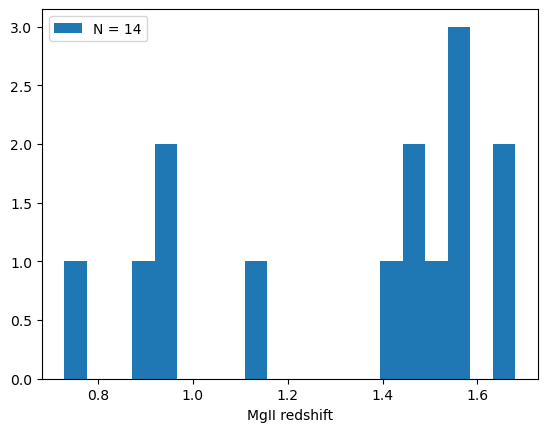

In [3]:
from qsoabsfind.datamodel import AbsorberData
mgii_tab = AbsorberData(f'../data/sdss/MgII_cat.fits', autoload=True)
zabs = mgii_tab.catalog["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('MgII redshift')

Text(0.5, 0, '$EW_{\\rm MgII}\\, [\\AA]$')

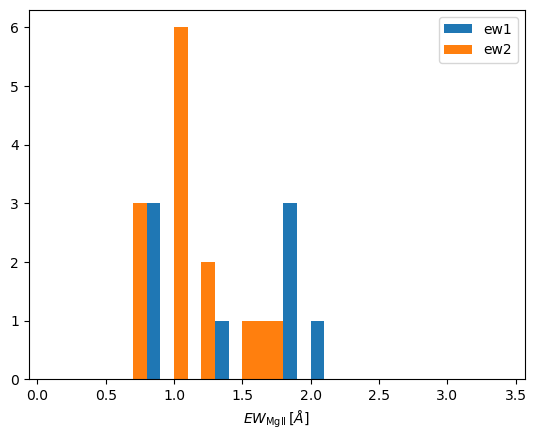

In [4]:
ew1 = mgii_tab.catalog["MGII_2796_EW"].data
ew2 = mgii_tab.catalog["MGII_2803_EW"].data
bins = np.arange(0.1, 3.5, 0.1)
plt.hist(ew1, bins=bins, label='ew1')
plt.hist(ew2, bins=bins, label = 'ew2')
plt.legend()
plt.xlabel(r'$EW_{\rm MgII}\, [\AA]$')

### Plotting spectra

INFO: plotting QSO INDEX = 24...
INFO: Time taken to read ../data/sdss/qso_test_spectra.fits 0.01 seconds


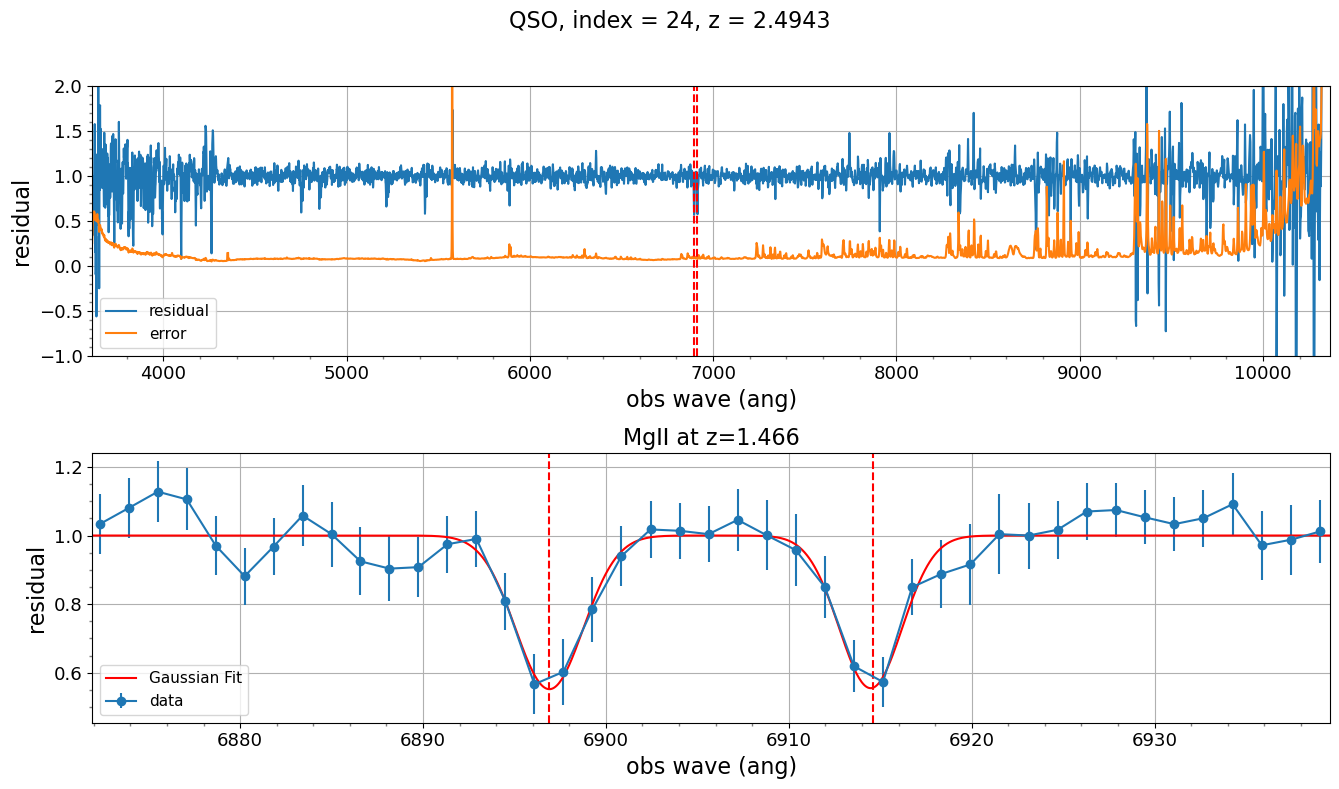

In [5]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead
import numpy as np

# select a random spectra from MgII_cat.fits
index = np.random.choice(mgii_tab.catalog["INDEX_SPEC"].data)
print(f'INFO: plotting QSO INDEX = {index}...')
spectra = QSOSpecRead(f'../data/sdss/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = mgii_tab.catalog[mgii_tab.catalog["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'MgII', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

### Using qsoabsfind internally as module

In [6]:
# if want to run qsoabsfind on one spectrum
from qsoabsfind.absfinder import read_single_spectrum_and_find_absorber
from qsoabsfind.config import load_constants
help(read_single_spectrum_and_find_absorber)

Help on function read_single_spectrum_and_find_absorber in module qsoabsfind.absfinder:

read_single_spectrum_and_find_absorber(fits_file, spec_index, absorber, **kwargs)
    This function retrieves a single QSO spectrum from a FITS file, processes the data to remove NaNs,
    and prepares the spectrum for absorber search within specified wavelength regions
    and runs the convolution based adaptive S/N method to detect absorbers in the spectrum.
    
    Args:
        fits_file (str): Path to the FITS file containing normalized QSO spectra.
                         The file must include extensions for FLUX, ERROR, WAVELENGTH
                         and METADATA which must contain keyword Z_QSO.
        spec_index (int): Index of the quasar spectrum to retrieve from the FITS file.
        absorber (str): Name of the absorber to search for (e.g., MgII, CIV, OVI, NV, SiIV, AlIII, FeII).
        kwargs (dict): search parameters as taken in convolution_method..()
    
    Returns:
      

In [7]:
parameters = load_constants(f'../data/sdss/sdss_constants.py')
read_single_spectrum_and_find_absorber(f'../data/sdss/qso_test_spectra.fits', index, 'MgII', **parameters.search_parameters)

/Users/abhijeet/software/myprojects/qsoabsfind/qsoabsfind/ew.py:76: RuntimeWarning: invalid value encountered in sqrt
  save_param_error = np.sqrt(np.diag(pcov))
/Users/abhijeet/opt/anaconda3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/abhijeet/opt/anaconda3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/abhijeet/software/myprojects/qsoabsfind/qsoabsfind/ew.py:76: RuntimeWarning: invalid value encountered in sqrt
  save_param_error = np.sqrt(np.diag(pcov))


{'index_spec': [24],
 'z_abs': [1.4663969873302762],
 'gauss_fit': [[0.447940346099861,
   2796.3503865411135,
   0.7502230480142372,
   0.4450303322583432,
   2803.4733065351206,
   0.6981444978068045]],
 'gauss_fit_std': [[0.07773801587410722,
   0.14694597720782263,
   0.14424750767206249,
   0.06717694500927203,
   0.13097833269595985,
   0.14022568067451605]],
 'ew_1_mean': [0.8423653841018677],
 'ew_2_mean': [0.7787980437278748],
 'ew_total_mean': [1.6211634874343872],
 'ew_1_error': [0.015775281935930252],
 'ew_2_error': [0.03886644169688225],
 'ew_total_error': [0.041945915669202805],
 'z_abs_err': [8.66716873133555e-05],
 'sn_1': [5.559768584999461],
 'sn_2': [5.834317580287034],
 'vel_disp1': [41.38364906347165],
 'vel_disp2': [28.587094305525046],
 'delta_chi2': [117.87179565429688]}

Reading extension 'PRIMARY' (PrimaryHDU)
Reading extension 'ABSORBER' (BinTableHDU)
Reading extension 'METADATA' (BinTableHDU)
Reading extension 'COLUMN_DENSITY' (BinTableHDU)
Loaded 4 extensions from ../data/sdss/CIV_cat.fits
  ABSORBER: 21 rows
  METADATA: 21 rows
  COLUMN_DENSITY: 21 rows
INFO: Time taken to read catalog from ../data/sdss/CIV_cat.fits 0.03 seconds
Reading extension 'PRIMARY' (PrimaryHDU)
Reading extension 'ABSORBER' (BinTableHDU)
Reading extension 'METADATA' (BinTableHDU)
Reading extension 'COLUMN_DENSITY' (BinTableHDU)
Loaded 4 extensions from ../data/sdss/CIV_cat.fits
  ABSORBER: 21 rows
  METADATA: 21 rows
  COLUMN_DENSITY: 21 rows
INFO: Time taken to read catalog from ../data/sdss/CIV_cat.fits 0.02 seconds


Text(0.5, 0, 'CIV redshift')

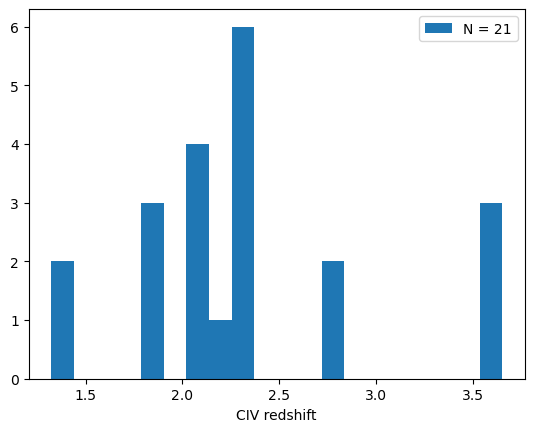

In [8]:
civ_tab = AbsorberData(f'../data/sdss/CIV_cat.fits')
civ_tab.read_catalog()
civ_zabs = civ_tab.catalog["Z_ABS"].data
plt.hist(civ_zabs, bins=20, label = f'N = {civ_zabs.size}')
plt.legend()
plt.xlabel('CIV redshift')

INFO: Time taken to read ../data/sdss/qso_test_spectra.fits 0.03 seconds
INFO: plotting CIV for QSO INDEX = 95...


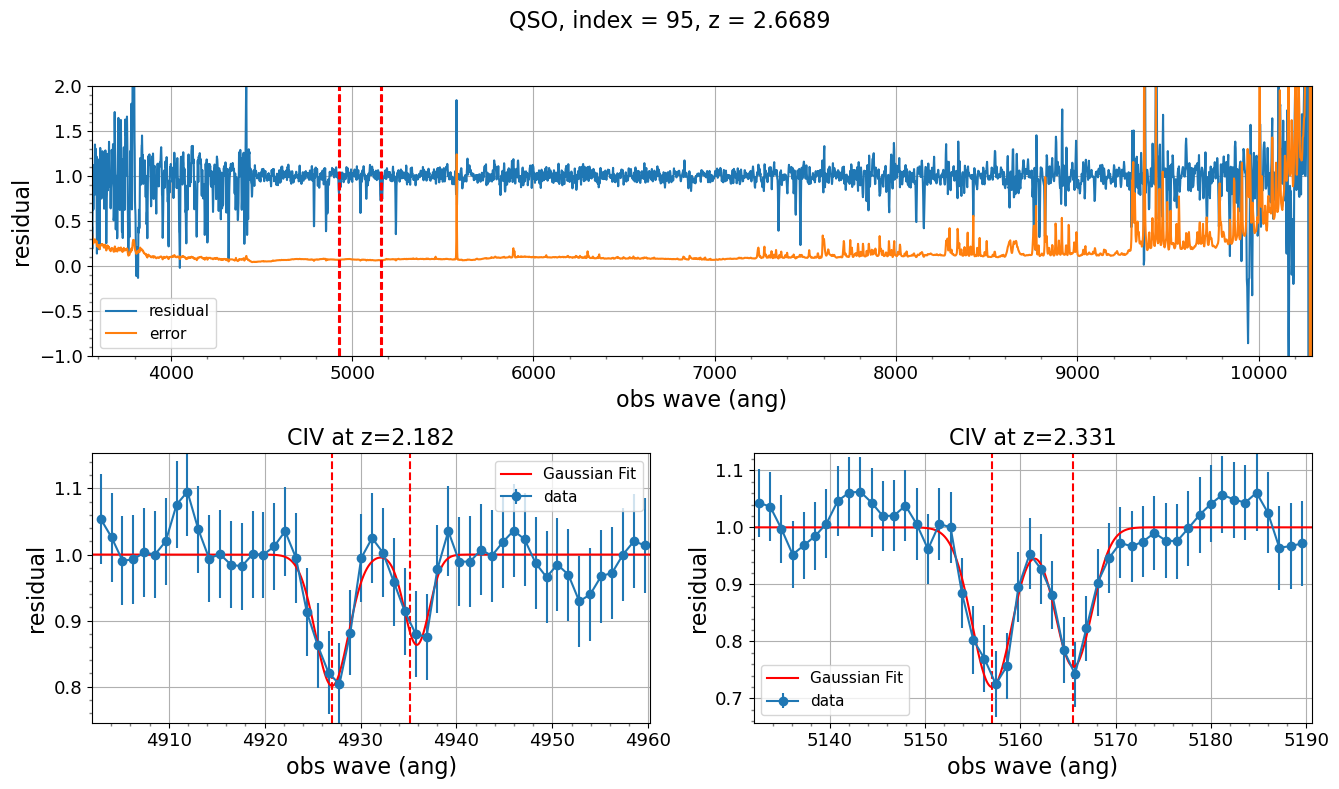

In [10]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead

# select a random spectra from CIV_cat.fits
index = np.random.choice(civ_tab.catalog["INDEX_SPEC"].data)
spectra = QSOSpecRead(f'../data/sdss/qso_test_spectra.fits', index=index, autoload=True)
print(f'INFO: plotting CIV for QSO INDEX = {index}...')
# select corresponding zabs table
zabs = civ_tab.catalog[civ_tab.catalog["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'CIV', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)